In [3]:
pip install mysql-connector-python

Note: you may need to restart the kernel to use updated packages.


In [1]:
pip install pandas

In [2]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [5]:
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set chart style globally

sns.set_theme(style = "whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

print("All libraries loaded successfully")

All libraries loaded successfully


In [9]:
# Connect to MySQL Database

conn = mysql.connector.connect(
    host = "localhost",
    user = "root",
    password = "Prasad@123",
    database = "supply_chain"
)

# Load the order table into a pandas dataframe

df = pd.read_sql(" SELECT * FROM orders ", conn)

# Close the connection once data is loaded
conn.close

print(f"Data loaded! Shape: {df.shape}")
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")

Data loaded! Shape: (180519, 51)
Rows: 180,519 | Columns: 51


In [11]:
pd.set_option('display.max_columns', None)
df.head()

,Type,Days_for_shipping_real,Days_for_shipment_scheduled,Benefit_per_order,Sales_per_customer,Delivery_Status,Late_delivery_risk,Category_Id,Category_Name,Customer_City,Customer_Country,Customer_Email,Customer_Fname,Customer_Id,Customer_Lname,Customer_Password,Customer_Segment,Customer_State,Customer_Street,Customer_Zipcode,Department_Id,Department_Name,Market,Order_City,Order_Country,Order_Customer_Id,order_date_DateOrders,Order_Id,Order_Item_Cardprod_Id,Order_Item_Discount,Order_Item_Discount_Rate,Order_Item_Id,Order_Item_Product_Price,Order_Item_Profit_Ratio,Order_Item_Quantity,Sales,Order_Item_Total,Order_Profit_Per_Order,Order_Region,Order_State,Order_Status,Order_Zipcode,Product_Card_Id,Product_Category_Id,Product_Description,Product_Image,Product_Name,Product_Price,Product_Status,shipping_date_DateOrders,Shipping_Mode
0,DEBIT,3,4,91.25,314.64,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Cally,20755,Holloway,XXXXXXXXX,Consumer,PR,5365 Noble Nectar Island,725,2,Fitness,Pacific Asia,Bekasi,Indonesia,20755,1/31/2018 22:56,77202,1360,13.11,0.04,180517,327.75,0.29,1,327.75,314.64,91.25,Southeast Asia,Java Occidental,COMPLETE,,1360,73,,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,02-03-2018 22:56,Standard Class
1,TRANSFER,5,4,-249.09,311.36,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Irene,19492,Luna,XXXXXXXXX,Consumer,PR,2679 Rustic Loop,725,2,Fitness,Pacific Asia,Bikaner,India,19492,1/13/2018 12:27,75939,1360,16.39,0.05,179254,327.75,-0.80,1,327.75,311.36,-249.09,South Asia,Rajastán,PENDING,,1360,73,,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.78,309.72,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,XXXXXXXXX,Gillian,19491,Maldonado,XXXXXXXXX,Consumer,CA,8510 Round Bear Gate,95125,2,Fitness,Pacific Asia,Bikaner,India,19491,1/13/2018 12:06,75938,1360,18.03,0.06,179253,327.75,-0.80,1,327.75,309.72,-247.78,South Asia,Rajastán,CLOSED,,1360,73,,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.86,304.81,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,XXXXXXXXX,Tana,19490,Tate,XXXXXXXXX,Home Office,CA,3200 Amber Bend,90027,2,Fitness,Pacific Asia,Townsville,Australia,19490,1/13/2018 11:45,75937,1360,22.94,0.07,179252,327.75,0.08,1,327.75,304.81,22.86,Oceania,Queensland,COMPLETE,,1360,73,,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.21,298.25,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Orli,19489,Hendricks,XXXXXXXXX,Corporate,PR,8671 Iron Anchor Corners,725,2,Fitness,Pacific Asia,Townsville,Australia,19489,1/13/2018 11:24,75936,1360,29.50,0.09,179251,327.75,0.45,1,327.75,298.25,134.21,Oceania,Queensland,PENDING_PAYMENT,,1360,73,,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [13]:
df.dtypes

Type                            object
Days_for_shipping_real           int64
Days_for_shipment_scheduled      int64
Benefit_per_order              float64
Sales_per_customer             float64
Delivery_Status                 object
Late_delivery_risk               int64
Category_Id                      int64
Category_Name                   object
Customer_City                   object
Customer_Country                object
Customer_Email                  object
Customer_Fname                  object
Customer_Id                      int64
Customer_Lname                  object
Customer_Password               object
Customer_Segment                object
Customer_State                  object
Customer_Street                 object
Customer_Zipcode                object
Department_Id                    int64
Department_Name                 object
Market                          object
Order_City                      object
Order_Country                   object
Order_Customer_Id        

In [16]:
# Check for missing values in every column

missing = df.isnull().sum()
missing_percent = (missing / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    'Missing Count' : missing,
    'Missing %' : missing_percent
}).query('`Missing Count` > 0').sort_values('Missing %', ascending = False)

print(missing_report)
    

Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


In [17]:
df.describe().round(2)

,Days_for_shipping_real,Days_for_shipment_scheduled,Benefit_per_order,Sales_per_customer,Late_delivery_risk,Category_Id,Customer_Id,Department_Id,Order_Customer_Id,Order_Id,Order_Item_Cardprod_Id,Order_Item_Discount,Order_Item_Discount_Rate,Order_Item_Id,Order_Item_Product_Price,Order_Item_Profit_Ratio,Order_Item_Quantity,Sales,Order_Item_Total,Order_Profit_Per_Order,Product_Card_Id,Product_Category_Id,Product_Price,Product_Status
count,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00,180519.0
mean,3.50,2.93,21.97,183.11,0.55,31.85,6691.38,5.44,6691.38,36221.89,692.51,20.66,0.10,90260.00,141.23,0.12,2.13,203.77,183.11,21.97,692.51,31.85,141.23,0.0
std,1.62,1.37,104.43,120.04,0.50,15.64,4162.92,1.63,4162.92,21045.38,336.45,21.80,0.07,52111.49,139.73,0.47,1.45,132.27,120.04,104.43,336.45,15.64,139.73,0.0
min,0.00,0.00,-4274.98,7.49,0.00,2.00,1.00,2.00,1.00,1.00,19.00,0.00,0.00,1.00,9.99,-2.75,1.00,9.99,7.49,-4274.98,19.00,2.00,9.99,0.0
25%,2.00,2.00,7.00,104.38,0.00,18.00,3258.50,4.00,3258.50,18057.00,403.00,5.40,0.04,45130.50,50.00,0.08,1.00,119.98,104.38,7.00,403.00,18.00,50.00,0.0
50%,3.00,4.00,31.52,163.99,1.00,29.00,6457.00,5.00,6457.00,36140.00,627.00,14.00,0.10,90260.00,59.99,0.27,1.00,199.92,163.99,31.52,627.00,29.00,59.99,0.0
75%,5.00,4.00,64.80,247.40,1.00,45.00,9779.00,7.00,9779.00,54144.00,1004.00,29.99,0.16,135389.50,199.99,0.36,3.00,299.95,247.40,64.80,1004.00,45.00,199.99,0.0
max,6.00,4.00,911.80,1939.99,1.00,76.00,20757.00,12.00,20757.00,77204.00,1363.00,500.00,0.25,180519.00,1999.99,0.50,5.00,1999.99,1939.99,911.80,1363.00,76.00,1999.99,0.0


# **Clean the Data**

In [19]:
df['order_date'] = pd.to_datetime(
    df['order_date_DateOrders'], 
    format = '%m/%d/%Y %H:%M',
    errors = 'coerce'
)

df['shipping_date'] = pd.to_datetime(
    df['shipping_date_DateOrders'], 
    format = '%m/%d/%Y %H:%M',
    errors = 'coerce'
)

print("Date Columns Converted!")
print(df[['order_date', 'shipping_date']].head())

Date Columns Converted!
           order_date       shipping_date
0 2018-01-31 22:56:00                 NaT
1 2018-01-13 12:27:00 2018-01-18 12:27:00
2 2018-01-13 12:06:00 2018-01-17 12:06:00
3 2018-01-13 11:45:00 2018-01-16 11:45:00
4 2018-01-13 11:24:00 2018-01-15 11:24:00


In [20]:
# Drop the columns that are not useful for analysis

cols_to_drop = [
    'Customer_Email', 'Customer_Password', 'Customer_Street', 
    'Customer_Zipcode', 'Product_Description', 'Product_Image',
    'order_date_DateOrders', 'shipping_date_DateOrders']

df.drop(columns = cols_to_drop, inplace = True)

print(f"Cleaned! Remaining Columns: {df.shape[1]}")


Cleaned! Remaining Columns: 45


In [22]:
# Fill missing values

df['Order_Zipcode'].fillna('Unknown', inplace = True)

# Confirm no missing value in key columns

key_cols = ['Delivery_Status', 'Late_delivery_risk', 'Days_for_shipping_real', 
            'Days_for_shipment_scheduled', 'Sales', 'Order_Profit_Per_Order']

print(" Missing Values in key Columns:")
print(df[key_cols].isnull().sum())

 Missing Values in key Columns:
Delivery_Status                0
Late_delivery_risk             0
Days_for_shipping_real         0
Days_for_shipment_scheduled    0
Sales                          0
Order_Profit_Per_Order         0
dtype: int64


In [27]:
# Create New Columns as 
# delivery_gap = how many days late or early was the actual delivery
# positive = late, negative = Early, Zero = On Time

df['delivery_gap'] = df['Days_for_shipping_real'] - df['Days_for_shipment_scheduled']

df['delayed'] = (df['delivery_gap'] > 0).astype(int)

df['order_month'] = df['order_date'].dt.to_period('M').astype(str)

print("New columns created!")
print(df[['delivery_gap', 'delayed', 'order_month']].head(10))


New columns created!
   delivery_gap  delayed order_month
0            -1        0     2018-01
1             1        1     2018-01
2             0        0     2018-01
3            -1        0     2018-01
4            -2        0     2018-01
5             2        1     2018-01
6             1        1     2018-01
7             1        1     2018-01
8             1        1     2018-01
9             1        1     2018-01


In [29]:
# Compare new column 'delayed' with original column Late_delivery_risk

print("comparing new column 'delayed' with original column 'Late_delivery_risk' :")
print(pd.crosstab(df['delayed'], df['Late_delivery_risk']))

comparing new column 'delayed' with original column 'Late_delivery_risk' :
Late_delivery_risk      0      1
delayed                         
0                   77119      0
1                    4423  98977


In [31]:
df.loc[
    (df['delayed'] == 1) & (df['Late_delivery_risk'] == 0),
    ['delayed', 'Late_delivery_risk']
]

,delayed,Late_delivery_risk
5,1,0
10,1,0
23,1,0
39,1,0
183,1,0
...,...,...
180309,1,0
180322,1,0
180323,1,0
180348,1,0


### The 4,423 mismatched rows are orders where actual days slightly exceeded scheduled days but the original system didn't flag them as risky — possibly because they were within an acceptable tolerance window.

In [32]:
# Align delay flag with original business logic

df['delayed'] = df['Late_delivery_risk']

# verify the mismatch again - should be zero now

print(pd.crosstab(df['delayed'], df['Late_delivery_risk']))

Late_delivery_risk      0      1
delayed                         
0                   81542      0
1                       0  98977


# Visualizations

##  Overall Delivery Status Breakdown

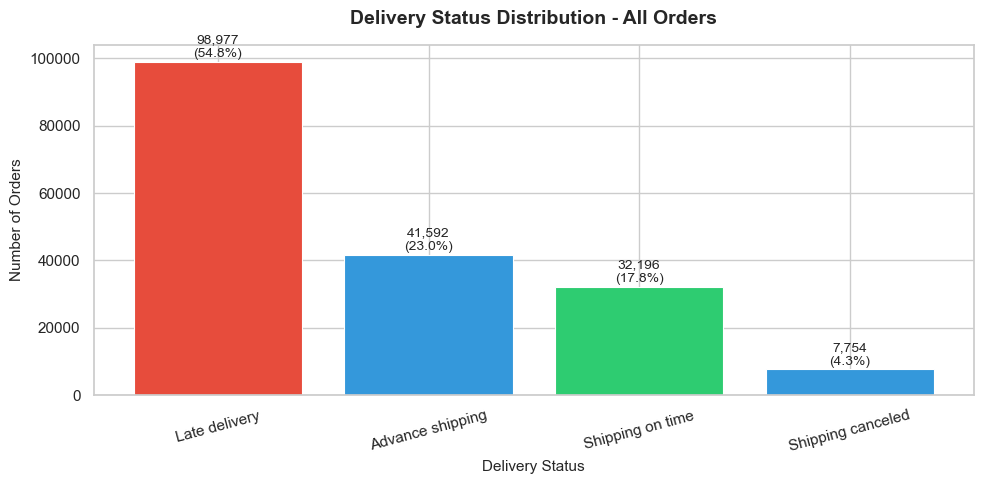

Chart 1 saved!


In [43]:
plt.figure(figsize = (10, 5))
status_counts = df['Delivery_Status'].value_counts()

colors = ['#e74c3c' if 'Late' in s 
          else '#2ecc71' if s == 'Shipping on time' 
          else '#3498db' 
          for s in status_counts.index]

bars = plt.bar(status_counts.index, status_counts.values, color = colors, edgecolor = 'white', linewidth = 0.8)

for bar, val in zip(bars, status_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=10)

plt.title('Delivery Status Distribution - All Orders', fontsize = 14, fontweight = 'bold', pad = 15)
plt.xlabel('Delivery Status', fontsize = 11 )
plt.ylabel('Number of Orders', fontsize = 11)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('chart1_delivery_status.png', dpi=150, bbox_inches = 'tight')
plt.show()
print("Chart 1 saved!")


## Late Delivery Rate by Shipping Mode

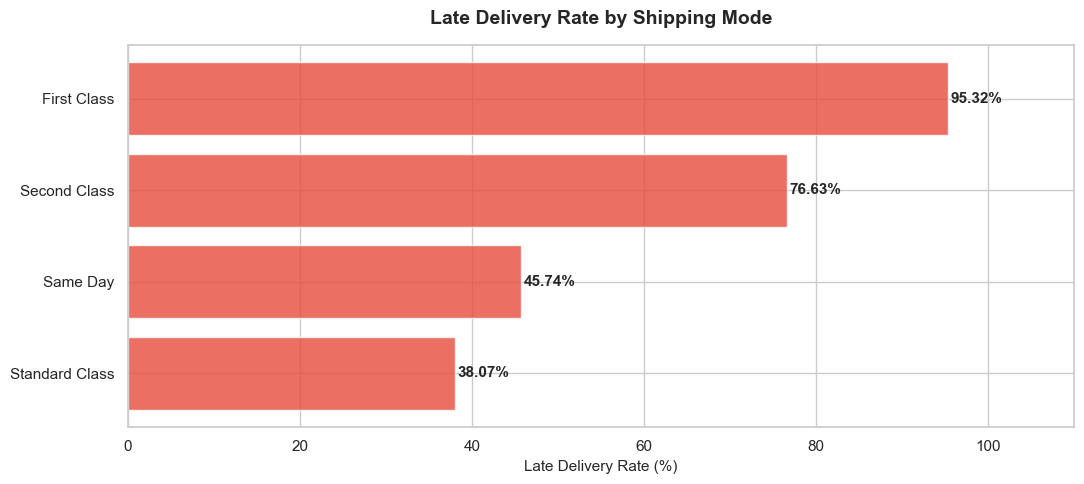

Chart 2 saved!


In [37]:
shipping_stats = df.groupby('Shipping_Mode'). agg(
    total_orders = ('Order_Id', 'count'),
    late_orders = ('delayed', 'sum'),
    avg_delay_gap = ('delivery_gap', 'mean')
).reset_index()

shipping_stats['late_pct'] = (shipping_stats['late_orders'] / shipping_stats['total_orders'] * 100).round(2)
shipping_stats = shipping_stats.sort_values('late_pct', ascending=True)

fig, ax1 = plt.subplots(figsize=(11, 5))

bars = ax1.barh(shipping_stats['Shipping_Mode'], shipping_stats['late_pct'],
                color='#e74c3c', alpha=0.8, edgecolor='white')

for bar, val in zip(bars, shipping_stats['late_pct']):
    ax1.text(val + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val}%', va='center', fontsize=11, fontweight='bold')

ax1.set_xlabel('Late Delivery Rate (%)', fontsize=11)
ax1.set_title('Late Delivery Rate by Shipping Mode', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlim(0, 110)

plt.tight_layout()
plt.savefig('chart2_shipping_mode.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved!")
                  

## Top 10 Product Categories by Late Orders

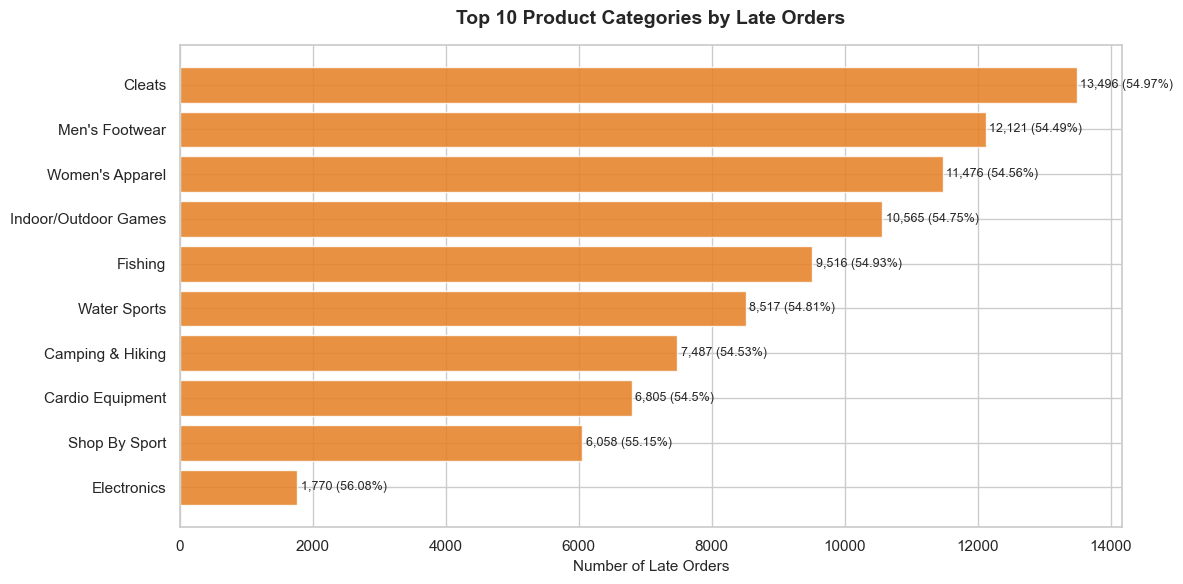

Chart 3 saved!


In [44]:
cat_stats = df.groupby('Category_Name').agg(
    total_orders=('Order_Id', 'count'),
    late_orders=('delayed', 'sum')
).reset_index()

cat_stats['late_pct'] = (cat_stats['late_orders'] / cat_stats['total_orders'] * 100).round(2)
top10 = cat_stats.sort_values('late_orders', ascending=False).head(10)
top10 = top10.sort_values('late_orders', ascending=True)

plt.figure(figsize=(12, 6))
bars = plt.barh(top10['Category_Name'], top10['late_orders'],
                color='#e67e22', alpha=0.85, edgecolor='white')

for bar, val, pct in zip(bars, top10['late_orders'], top10['late_pct']):
    plt.text(val + 50, bar.get_y() + bar.get_height()/2,
             f'{val:,} ({pct}%)', va='center', fontsize=9)

plt.xlabel('Number of Late Orders', fontsize=11)
plt.title('Top 10 Product Categories by Late Orders', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('chart3_product_categories.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved!")

## Delivery Gap Distribution

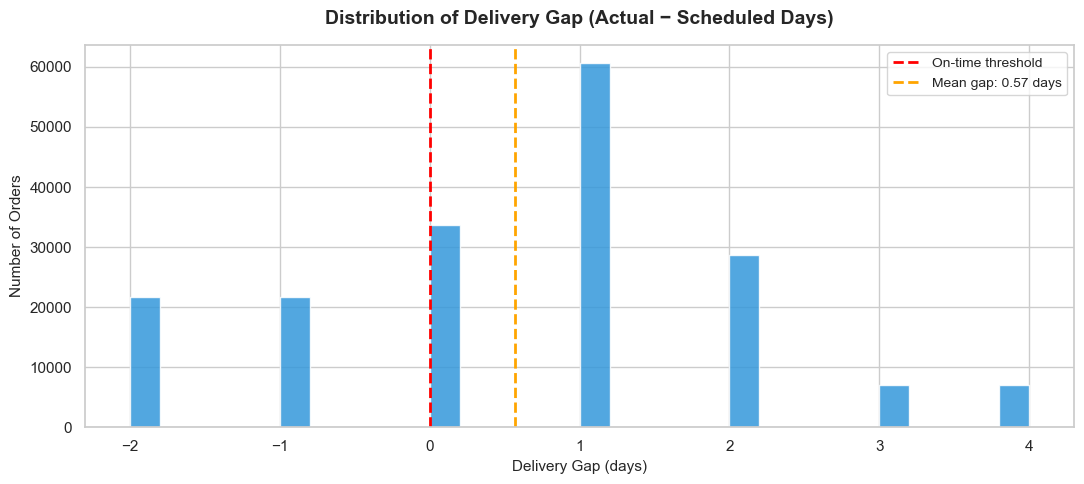

Chart 4 saved!


In [45]:
plt.figure(figsize=(11, 5))

plt.hist(df['delivery_gap'], bins=30, color='#3498db', edgecolor='white', alpha=0.85)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='On-time threshold')
plt.axvline(x=df['delivery_gap'].mean(), color='orange', linestyle='--', 
            linewidth=2, label=f"Mean gap: {df['delivery_gap'].mean():.2f} days")

plt.title('Distribution of Delivery Gap (Actual − Scheduled Days)', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Delivery Gap (days)', fontsize=11)
plt.ylabel('Number of Orders', fontsize=11)
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('chart4_delivery_gap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved!")

## Monthly Late Delivery Trend

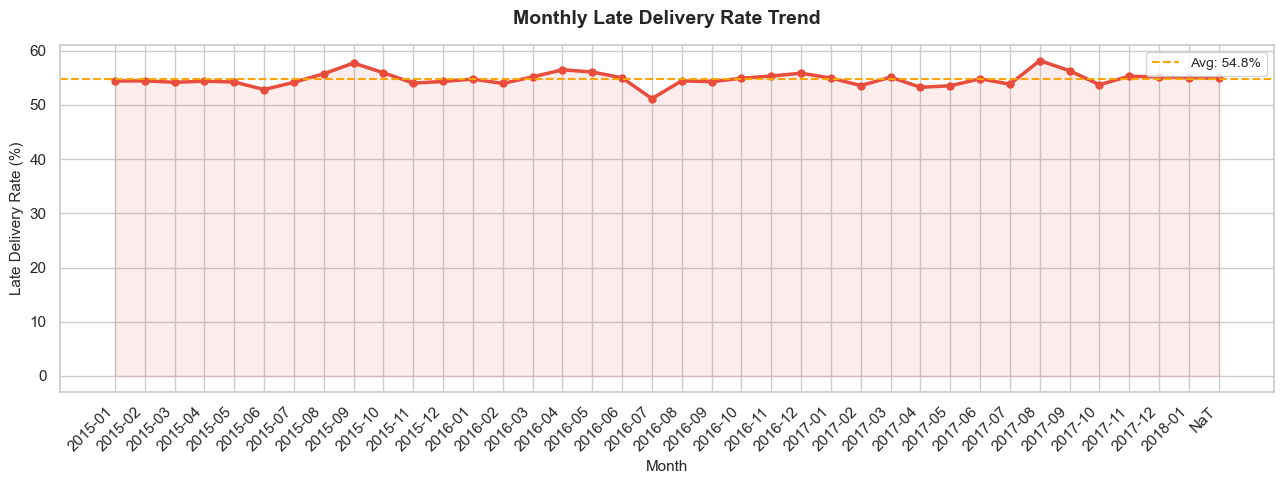

Chart 5 saved!


In [46]:
monthly = df.groupby('order_month').agg(
    total=('Order_Id', 'count'),
    late=('delayed', 'sum')
).reset_index()
monthly['late_pct'] = (monthly['late'] / monthly['total'] * 100).round(2)
monthly = monthly.sort_values('order_month')

plt.figure(figsize=(13, 5))
plt.plot(monthly['order_month'], monthly['late_pct'], 
         color='#e74c3c', linewidth=2.5, marker='o', markersize=5)
plt.fill_between(monthly['order_month'], monthly['late_pct'], 
                 alpha=0.1, color='#e74c3c')

plt.axhline(y=monthly['late_pct'].mean(), color='orange', linestyle='--',
            linewidth=1.5, label=f"Avg: {monthly['late_pct'].mean():.1f}%")

plt.title('Monthly Late Delivery Rate Trend', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Month', fontsize=11)
plt.ylabel('Late Delivery Rate (%)', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('chart5_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 5 saved!")

## Profit vs Late Delivery Rate by Customer Segment

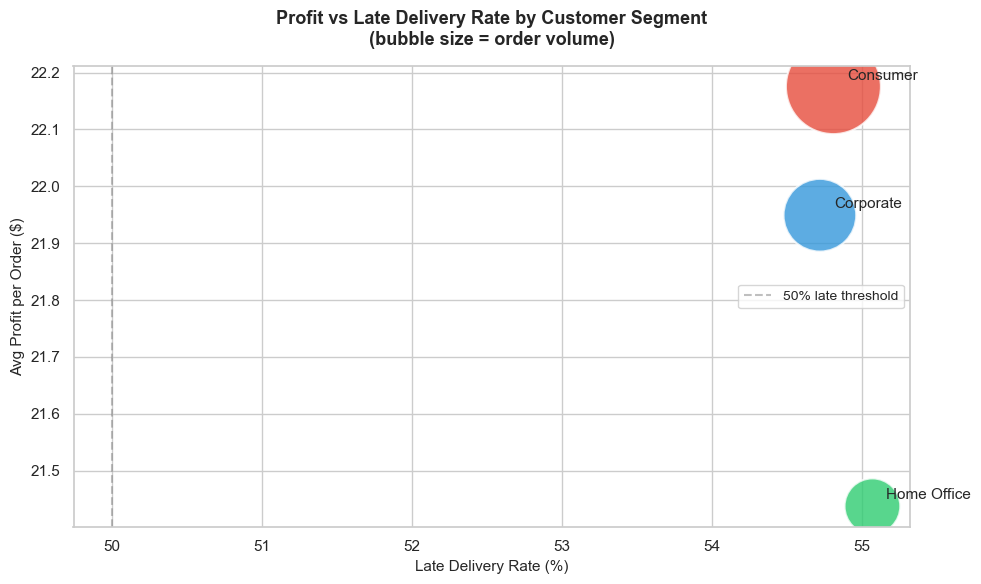

Chart 6 saved!


In [49]:
seg_stats = df.groupby('Customer_Segment').agg(
    avg_profit=('Order_Profit_Per_Order', 'mean'),
    late_pct=('delayed', 'mean'),
    total_orders=('Order_Id', 'count')
).reset_index()
seg_stats['late_pct'] = (seg_stats['late_pct'] * 100).round(2)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    seg_stats['late_pct'],
    seg_stats['avg_profit'],
    s=seg_stats['total_orders'] / 20,
    c=['#e74c3c', '#3498db', '#2ecc71'],
    alpha=0.8, edgecolors='white', linewidth=1.5
)

for _, row in seg_stats.iterrows():
    plt.annotate(row['Customer_Segment'],
                 (row['late_pct'], row['avg_profit']),
                 textcoords="offset points", xytext=(10, 5), fontsize=11)

plt.axvline(x=50, color='gray', linestyle='--', alpha=0.5, label='50% late threshold')
plt.xlabel('Late Delivery Rate (%)', fontsize=11)
plt.ylabel('Avg Profit per Order ($)', fontsize=11)
plt.title('Profit vs Late Delivery Rate by Customer Segment\n(bubble size = order volume)',
          fontsize=13, fontweight='bold', pad=15)
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('chart6_segment_profit.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 6 saved!")

In [50]:
#  Save the Cleaned Dataset for Power BI

df.to_csv('supply_chain_cleaned.csv', index=False)
print(f"Cleaned dataset saved! Shape: {df.shape}")
print("File: supply_chain_cleaned.csv")

Cleaned dataset saved! Shape: (180519, 48)
File: supply_chain_cleaned.csv
